<a href="https://colab.research.google.com/github/Aswini-Raj/ML_Algorithms/blob/main/Titanic_Passenger_Survival_Prediction_using_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [185]:
df=pd.read_csv('/content/drive/MyDrive/titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [186]:
df.shape

(891, 12)

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [188]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [189]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [190]:
dfnum = df.select_dtypes(include='number')
dfcat = df.select_dtypes(include='object')

In [191]:
dfnum


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,NaN,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


In [192]:
dfcat

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S
...,...,...,...,...,...
886,"Montvila, Rev. Juozas",male,211536,NaN,S
887,"Graham, Miss. Margaret Edith",female,112053,B42,S
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,NaN,S
889,"Behr, Mr. Karl Howell",male,111369,C148,C


<Axes: >

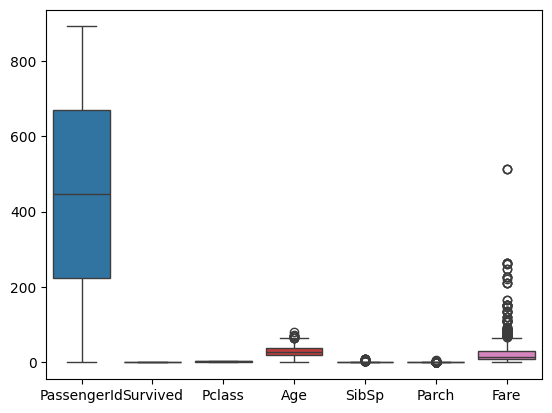

In [193]:
sns.boxplot(dfnum)

In [194]:
dfnum['Age']=dfnum['Age'].fillna(dfnum['Age'].median())
col=['Cabin','Embarked']
for c in col:
  dfcat[c]=dfcat[c].fillna(dfcat[c].mode()[0])

In [195]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [196]:
dfcat

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,B96 B98,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,B96 B98,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,B96 B98,S
...,...,...,...,...,...
886,"Montvila, Rev. Juozas",male,211536,B96 B98,S
887,"Graham, Miss. Margaret Edith",female,112053,B42,S
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,B96 B98,S
889,"Behr, Mr. Karl Howell",male,111369,C148,C


In [197]:
dfnum.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0


In [198]:
dfcat.isnull().sum()

,0
Name,0
Sex,0
Ticket,0
Cabin,0
Embarked,0


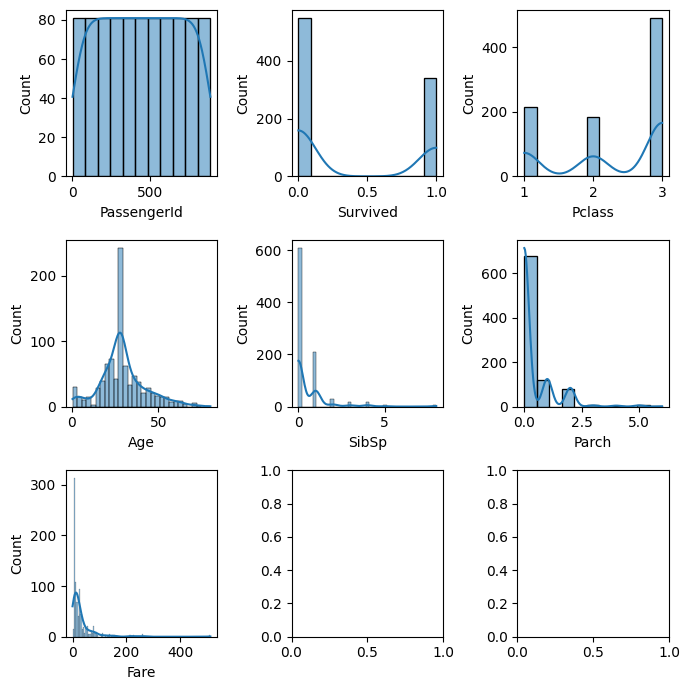

In [199]:
fig, ax = plt.subplots(3, 3, figsize=(7, 7))
axes_list = ax.flatten()

for col, current_ax in zip(dfnum.columns, axes_list):
    sns.histplot(dfnum[col], kde=True, ax=current_ax)

plt.tight_layout()
plt.show()

In [200]:
dfnum.skew()

,0
PassengerId,0.000000
Survived,0.478523
Pclass,-0.630548
Age,0.510245
SibSp,3.695352
Parch,2.749117
Fare,4.787317


In [201]:
cols=dfnum.drop('PassengerId',axis=1).columns
Q1=dfnum[cols].quantile(0.25)
Q3=dfnum[cols].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers = dfnum[((dfnum[cols] < lower_bound) | (dfnum[cols] > upper_bound)).any(axis=1)]
outliers

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
1,2,1,1,38.0,1,0,71.2833
7,8,0,3,2.0,3,1,21.0750
8,9,1,3,27.0,0,2,11.1333
10,11,1,3,4.0,1,1,16.7000
11,12,1,1,58.0,0,0,26.5500
...,...,...,...,...,...,...,...
871,872,1,1,47.0,1,1,52.5542
879,880,1,1,56.0,0,1,83.1583
880,881,1,2,25.0,0,1,26.0000
885,886,0,3,39.0,0,5,29.1250


In [202]:
remaining_iqr = ((dfnum[cols] < lower_bound) | (dfnum[cols] > upper_bound)).sum()
print("Remaining IQR outliers per column:\n", remaining_iqr)

Remaining IQR outliers per column:
 Survived      0
Pclass        0
Age          66
SibSp        46
Parch       213
Fare        116
dtype: int64


In [203]:
outliers

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
1,2,1,1,38.0,1,0,71.2833
7,8,0,3,2.0,3,1,21.0750
8,9,1,3,27.0,0,2,11.1333
10,11,1,3,4.0,1,1,16.7000
11,12,1,1,58.0,0,0,26.5500
...,...,...,...,...,...,...,...
871,872,1,1,47.0,1,1,52.5542
879,880,1,1,56.0,0,1,83.1583
880,881,1,2,25.0,0,1,26.0000
885,886,0,3,39.0,0,5,29.1250


In [204]:
from scipy.stats.mstats import winsorize

cols=['Age','SibSp']
for c in cols:
  dfnum[c]=winsorize(dfnum[c],limits=[0.1,0.1])

In [205]:
from scipy.stats.mstats import winsorize

cols=['Parch','Fare']
for c in cols:
  dfnum[c]=winsorize(dfnum[c],limits=[0.5,0.5])

In [206]:
dfnum

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,14.4542
1,2,1,1,38.0,1,0,14.4542
2,3,1,3,26.0,0,0,14.4542
3,4,1,1,35.0,1,0,14.4542
4,5,0,3,35.0,0,0,14.4542
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,14.4542
887,888,1,1,19.0,0,0,14.4542
888,889,0,3,28.0,1,0,14.4542
889,890,1,1,26.0,0,0,14.4542


<Axes: >

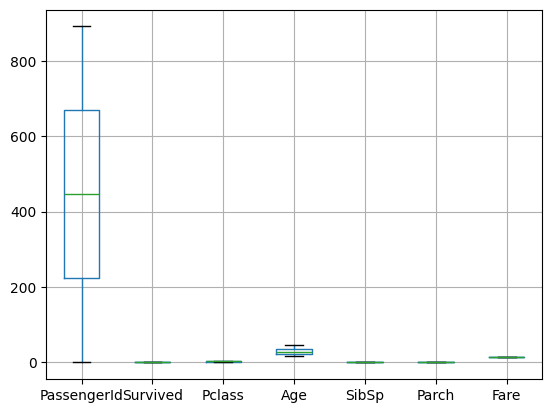

In [207]:
dfnum.boxplot()

In [220]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
for col in dfcat.columns:
  dfcat[col]=le.fit_transform(dfcat[col])


In [221]:
df_final = pd.concat([dfnum, dfcat], axis=1)

In [222]:
df_final

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Name,Sex,Ticket,Cabin,Embarked
0,1,0,3,22.0,1,0,14.4542,108,1,523,47,2
1,2,1,1,38.0,1,0,14.4542,190,0,596,81,0
2,3,1,3,26.0,0,0,14.4542,353,0,669,47,2
3,4,1,1,35.0,1,0,14.4542,272,0,49,55,2
4,5,0,3,35.0,0,0,14.4542,15,1,472,47,2
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,14.4542,548,1,101,47,2
887,888,1,1,19.0,0,0,14.4542,303,0,14,30,2
888,889,0,3,28.0,1,0,14.4542,413,0,675,47,2
889,890,1,1,26.0,0,0,14.4542,81,1,8,60,0


In [223]:
X=df_final.drop(['Survived'],axis=1)
y=df_final['Survived']

In [224]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [225]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [227]:
y_pred = rf_model.predict(X_test)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 0])

In [228]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8268156424581006

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86       105
           1       0.84      0.72      0.77        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.82       179


Confusion Matrix:
 [[95 10]
 [21 53]]
